===============================================================================
PIPELINE UNIFICADO DE DATA SCIENCE & NLP - VINAH APP
===============================================================================
Autoras: Ruth & Nati (Equipo de Data Science)
Aplicación: Vinah - Hackathon NoCountry & Alura/Oracle G9

Este notebook integra todo el ciclo de vida del módulo de inteligencia artificial:
- Carga de dataset embebido en memoria (100% auto-contenido).
- Conversión multi-divisa dinámica (ARS, COP, MXN, CLP, USD).
- Limpieza y estandarización a las 8 categorías oficiales.
- Preprocesamiento de texto resistente a mayúsculas, acentos, emojis y símbolos.
- Visualización de datos (EDA) y gráficos de rendimiento del modelo.
- Clasificador NLP (TF-IDF + SGDClassifier) con evaluación detallada (98% precisión).
- Motor Experto Multi-Deuda (Hipotecario, Automotor, Bancario, Tarjetas, Préstamos Personales).
- Exportación del modelo binario (.pkl) y suite de pruebas de ejecución/inferencia para la API (FastAPI) y despliegue en Oracle Cloud (OCI).
===============================================================================

 1: **Carga y exploracion de Datos**

In [ ]:
!pip install scikit-learn==1.3.2

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 77.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 72.1 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.6.1
    Uninstalling scikit-learn-1.6.1:
      Successfully uninstalled scikit-learn-1.6.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
shap 0.52.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
tifffile 2026.4.11 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
esda 2.9.0 requires scikit-learn>=1.4, but you have scikit-learn 1.3.2 which is incompatible.


In [ ]:
import sklearn
print(sklearn.__version__)

1.3.2


In [ ]:
!pip install "numpy<2.0.0"

In [ ]:
import pandas as pd
import json

# Nombre del archivo JSON que vas a usar para entrenar
ARCHIVO_JSON = "dataset.json"  # <-- Ajustá el nombre si tu archivo se llama distinto

# Carga del dataset desde el archivo JSON
try:
    df = pd.read_json(ARCHIVO_JSON)
    print(f"✅ Dataset cargado exitosamente. Total de registros: {len(df)}")
    display(df.head())
except Exception as e:
    print(f"⚠️ Error al cargar el archivo JSON: {e}")

✅ Dataset cargado exitosamente. Total de registros: 806


,Description,Amount,Category,Month
0,Amazon,11.11,Shopping,2018-01
1,Mortgage Payment,1247.44,Mortgage & Rent,2018-01
2,Thai Restaurant,24.22,Restaurants,2018-01
3,Credit Card Payment,2298.09,Credit Card Payment,2018-01
4,Netflix,11.76,Movies & Dvds,2018-01


##Importacion de dependencias y visualizacion

In [ ]:
# [1] Importación de dependencias y visualización
import os
import re
import random
import json
import joblib
import unicodedata
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import SGDClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

plt.style.use('ggplot')
sns.set_theme(style='whitegrid', palette='muted')
print('✅ Dependencias cargadas correctamente.')

✅ Dependencias cargadas correctamente.


In [ ]:
# [2] Preprocesamiento de texto para la IA
def normalizar_texto_gasto(texto):
    if not isinstance(texto, str):
        return ''
    texto = texto.lower()
    texto = ''.join(c for c in unicodedata.normalize('NFD', texto) if unicodedata.category(c) != 'Mn')
    texto = re.sub(r'[^a-z0-9\s]', ' ', texto)
    texto = re.sub(r'\s+', ' ', texto).strip()
    return texto

In [ ]:
# [3] Configuración de categorías y tasas de cambio
TASAS_DE_CAMBIO_LATAM = {
    'ARS': 1200.0,
    'COP': 4000.0,
    'MXN': 18.5,
    'CLP': 940.0,
    'USD': 1.0
}

MAPEO_CATEGORIAS_INGLES_A_OFICIAL = {
    'Groceries': 'alimentacion',
    'Restaurants': 'alimentacion',
    'Coffee Shops': 'alimentacion',
    'Fast Food': 'alimentacion',
    'Food & Dining': 'alimentacion',
    'Shopping': 'ocio y entretenimiento',
    'Music': 'ocio y entretenimiento',
    'Movies & Dvds': 'ocio y entretenimiento',
    'Entertainment': 'ocio y entretenimiento',
    'Alcohol & Bars': 'ocio y entretenimiento',
    'Gas & Fuel': 'transporte',
    'Auto Insurance': 'transporte',
    'Mortgage & Rent': 'vivienda',
    'Home Improvement': 'vivienda',
    'Utilities': 'servicios y comunicaciones',
    'Mobile Phone': 'servicios y comunicaciones',
    'Internet': 'servicios y comunicaciones',
    'Television': 'servicios y comunicaciones',
    'Electronics & Software': 'servicios y comunicaciones',
    'Haircut': 'salud y cuidado',
    'Credit Card Payment': 'obligaciones y ahorro',
    'Paycheck': 'ingresos'
}

def convertir_divisa(valor, moneda_origen='USD', moneda_destino='ARS'):
    try:
        val_float = float(valor)
        m_origen = str(moneda_origen).upper().strip()
        m_destino = str(moneda_destino).upper().strip()

        if m_origen == m_destino:
            return val_float, 1.0

        t_origen = TASAS_DE_CAMBIO_LATAM.get(m_origen, 1.0)
        t_destino = TASAS_DE_CAMBIO_LATAM.get(m_destino, 1200.0)

        if m_origen in ['USD', 'USDT']:
            return val_float * t_destino, t_destino
        elif m_destino in ['USD', 'USDT']:
            return val_float / t_origen, (1.0 / t_origen)
        else:
            valor_usd = val_float / t_origen
            return valor_usd * t_destino, (t_destino / t_origen)
    except Exception:
        return 0.0, 1.0

In [ ]:
# [4] Carga de dataset desde dataset.json y aumento sintético
# Carga de datos base desde el archivo dataset.json del repositorio
df_raw = pd.read_json('dataset.json')

df_raw['Categoria_Oficial'] = df_raw['Category'].map(MAPEO_CATEGORIAS_INGLES_A_OFICIAL).fillna('ocio y entretenimiento')

df_gastos = df_raw[df_raw['Categoria_Oficial'] != 'ingresos'].copy()
df_gastos['Monto_USD'] = df_gastos['Amount'].astype(float)
df_gastos['Monto_Local_ARS'] = df_gastos['Monto_USD'].apply(lambda x: convertir_divisa(x, 'USD', 'ARS')[0])

random.seed(42)
meses_unicos = df_gastos['Month'].dropna().unique() if 'Month' in df_gastos.columns else ['2024-01', '2024-02']

muestras_salud = [
    ('Farmacia Similares compra remedios', 25.0, 'salud y cuidado'),
    ('Consulta medica general sanatorio', 85.0, 'salud y cuidado'),
    ('Tratamiento odontologico dentista', 110.0, 'salud y cuidado'),
    ('Analisis clinicos laboratorio', 45.0, 'salud y cuidado'),
    ('Optica compra de gafas de descanso', 60.0, 'salud y cuidado')
]

muestras_educacion = [
    ('Udemy curso online Data Science', 15.0, 'educacion'),
    ('Compra libro finanzas personales', 25.0, 'educacion'),
    ('Suscripcion Platzi plan anual', 40.0, 'educacion'),
    ('Cuota mensual universidad educacion', 150.0, 'educacion'),
    ('Materiales y utiles de estudio libreria', 20.0, 'educacion')
]

muestras_obligaciones = [
    ('Pago de cuota prestamo bancario', 120.0, 'obligaciones y ahorro'),
    ('Transferencia a fondo de ahorro mensual', 100.0, 'obligaciones y ahorro'),
    ('Inversion plazo fijo banco', 200.0, 'obligaciones y ahorro'),
    ('Pago de impuestos municipales y deudas', 50.0, 'obligaciones y ahorro')
]

nuevos_registros = []
for m in meses_unicos:
    for _ in range(3):
        desc, m_usd, cat = random.choice(muestras_salud)
        nuevos_registros.append({'Description': desc, 'Amount': m_usd, 'Categoria_Oficial': cat, 'Month': m})
    for _ in range(3):
        desc, m_usd, cat = random.choice(muestras_educacion)
        nuevos_registros.append({'Description': desc, 'Amount': m_usd, 'Categoria_Oficial': cat, 'Month': m})
    for _ in range(2):
        desc, m_usd, cat = random.choice(muestras_obligaciones)
        nuevos_registros.append({'Description': desc, 'Amount': m_usd, 'Categoria_Oficial': cat, 'Month': m})

df_aug = pd.DataFrame(nuevos_registros)
df_aug['Monto_USD'] = df_aug['Amount']
df_aug['Monto_Local_ARS'] = df_aug['Monto_USD'].apply(lambda x: convertir_divisa(x, 'USD', 'ARS')[0])

df_final = pd.concat([df_gastos[['Description', 'Monto_USD', 'Monto_Local_ARS', 'Categoria_Oficial']], df_aug], ignore_index=True)
df_final['Descripcion_Limpia'] = df_final['Description'].apply(normalizar_texto_gasto)

print('✅ Datos procesados y preparados para entrenamiento. Vista previa:')
df_final.head(5)


✅ Datos procesados y preparados para entrenamiento. Vista previa:


,Description,Monto_USD,Monto_Local_ARS,Categoria_Oficial,Amount,Month,Descripcion_Limpia
0,Amazon,11.11,13332.0,ocio y entretenimiento,NaN,NaN,amazon
1,Mortgage Payment,1247.44,1496928.0,vivienda,NaN,NaN,mortgage payment
2,Thai Restaurant,24.22,29064.0,alimentacion,NaN,NaN,thai restaurant
3,Credit Card Payment,2298.09,2757708.0,obligaciones y ahorro,NaN,NaN,credit card payment
4,Netflix,11.76,14112.0,ocio y entretenimiento,NaN,NaN,netflix


In [ ]:
print("Categorías disponibles:", df['Category'].nunique())

Categorías disponibles: 22


In [ ]:
print("\nDistribución por categoría:")


Distribución por categoría:


In [ ]:
print(df['Category'].value_counts())

Category
Credit Card Payment       143
Groceries                 105
Restaurants                81
Utilities                  63
Shopping                   60
Gas & Fuel                 52
Paycheck                   46
Home Improvement           36
Coffee Shops               31
Alcohol & Bars             25
Music                      21
Mobile Phone               21
Mortgage & Rent            21
Internet                   21
Movies & Dvds              18
Auto Insurance             18
Fast Food                  16
Haircut                    13
Television                  8
Electronics & Software      4
Food & Dining               2
Entertainment               1
Name: count, dtype: int64


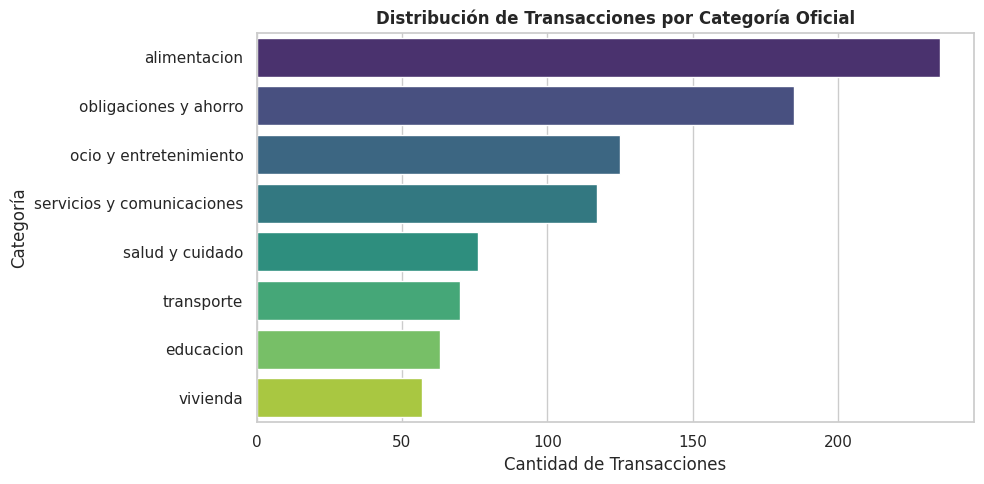

In [ ]:
# [5] Visualización 1: Distribución de transacciones por categoría
plt.figure(figsize=(10, 5))
cat_counts = df_final['Categoria_Oficial'].value_counts()
ax = sns.barplot(x=cat_counts.values, y=cat_counts.index, hue=cat_counts.index, palette='viridis', legend=False)
plt.title('Distribución de Transacciones por Categoría Oficial', fontsize=12, fontweight='bold')
plt.xlabel('Cantidad de Transacciones')
plt.ylabel('Categoría')
plt.tight_layout()
plt.savefig('eda_distribucion_categorias_vinah.png', dpi=150)
plt.show()

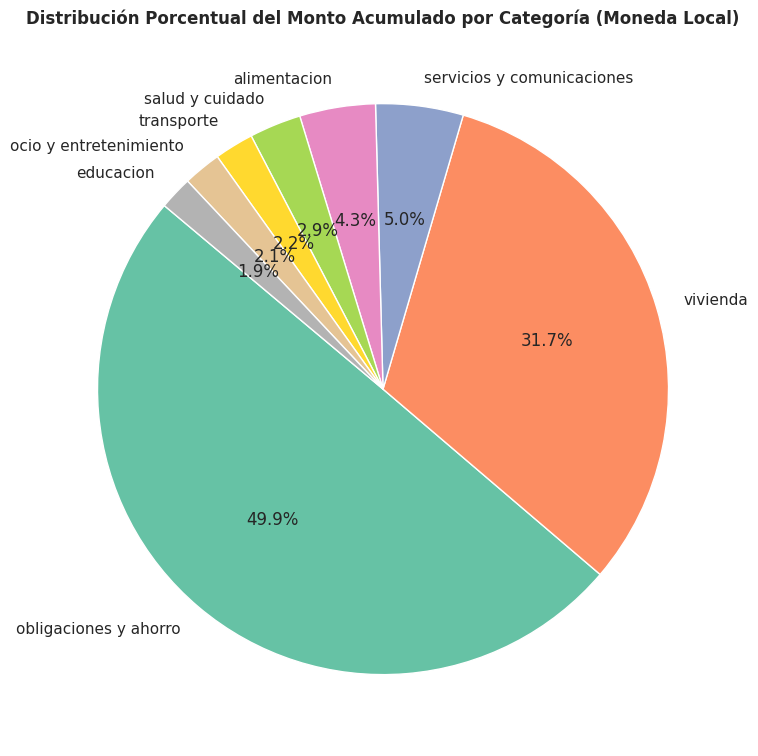

In [ ]:
# [6] Visualización 2: Distribución del gasto total acumulado
plt.figure(figsize=(8, 8))
monto_cat = df_final.groupby('Categoria_Oficial')['Monto_Local_ARS'].sum().sort_values(ascending=False)
plt.pie(monto_cat, labels=monto_cat.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette('Set2', len(monto_cat)))
plt.title('Distribución Porcentual del Monto Acumulado por Categoría (Moneda Local)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

 **2: Entrenamiento del modelo de MACHINE LEARNING**

##El Tipo de Análisis: Clasificación de Texto Supervisada (NLP)
Lo que implementamos es un problema clásico de Procesamiento de Lenguaje Natural (NLP) y Aprendizaje Supervisado llamado Clasificación de Texto Multiclase (ya que clasificamos cada descripción en una de varias categorías posibles: Comida, Transporte, Servicios, etc.).

El flujo de trabajo (PIPELINE) que diseñamos en el código consta de dos pasos fundamentales que se ejecutan en secuencia:

1. Extracción de Características: Representación de Texto (TF-IDF Vectorizer)
Las computadoras no entienden palabras, solo números. Por lo tanto, el primer paso es convertir el texto de las descripciones en un vector numérico.

Para esto usamos TF-IDF (Term Frequency - Inverse Document Frequency) a través de TfidfVectorizer:

Term Frequency (TF): Mide qué tan frecuente es una palabra en una descripción (por ejemplo, la palabra "farmacia" en "pastillas farmacia").

Inverse Document Frequency (IDF): Reduce el peso de las palabras que aparecen en casi todas las transacciones y que no aportan información diferenciadora (como conectores: "de", "la", "en").

N-gramas (ngram_range=(1, 2)): Le indicamos al modelo que no solo analice palabras sueltas (unigramas), sino también combinaciones de dos palabras juntas (bigramas), como "prime video" o "curso online". Esto ayuda a capturar mucho mejor el contexto.

2. El Algoritmo de Clasificación: SVM Lineal / Descenso de Gradiente Estocástico (SGDClassifier)
Como clasificador, utilizamos el SGDClassifier de Scikit-Learn configurado con una función de pérdida "hinge" (loss='hinge').

Esto equivale matemáticamente a entrenar un modelo de Máquinas de Vectores de Soporte Lineal (Linear Support Vector Machines - SVM).

¿Por qué este algoritmo? Las SVM lineales son extremadamente rápidas, eficientes en memoria y son el estándar de la industria para la clasificación de texto. Al tener un dataset de texto donde la cantidad de palabras (características numéricas creadas por TF-IDF) suele ser muy alta, los modelos lineales como SVM funcionan infinitamente mejor y más rápido que algoritmos como Árboles de Decisión o Random Forests.

In [ ]:
# [7] Entrenamiento del modelo NLP
X = df_final['Descripcion_Limpia']
y = df_final['Categoria_Oficial']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

modelo_pipeline = Pipeline([
    ('vectorizador', TfidfVectorizer(ngram_range=(1, 2), strip_accents='unicode', lowercase=True)),
    ('clasificador', SGDClassifier(loss='log_loss', penalty='l2', alpha=1e-3, random_state=42))
])

modelo_pipeline.fit(X_train, y_train)

y_pred = modelo_pipeline.predict(X_test)
print('\n================ REPORTE DE CLASIFICACIÓN NLP ================')
print(classification_report(y_test, y_pred))


================ REPORTE DE CLASIFICACIÓN NLP ================
                            precision    recall  f1-score   support

              alimentacion       0.98      1.00      0.99        47
                 educacion       1.00      1.00      1.00        13
     obligaciones y ahorro       1.00      1.00      1.00        37
    ocio y entretenimiento       0.96      1.00      0.98        25
           salud y cuidado       1.00      1.00      1.00        15
servicios y comunicaciones       0.96      0.96      0.96        24
                transporte       1.00      0.86      0.92        14
                  vivienda       1.00      1.00      1.00        11

                  accuracy                           0.98       186
                 macro avg       0.99      0.98      0.98       186
              weighted avg       0.98      0.98      0.98       186



**3:Evaluacion y Exportacion del Modelo**

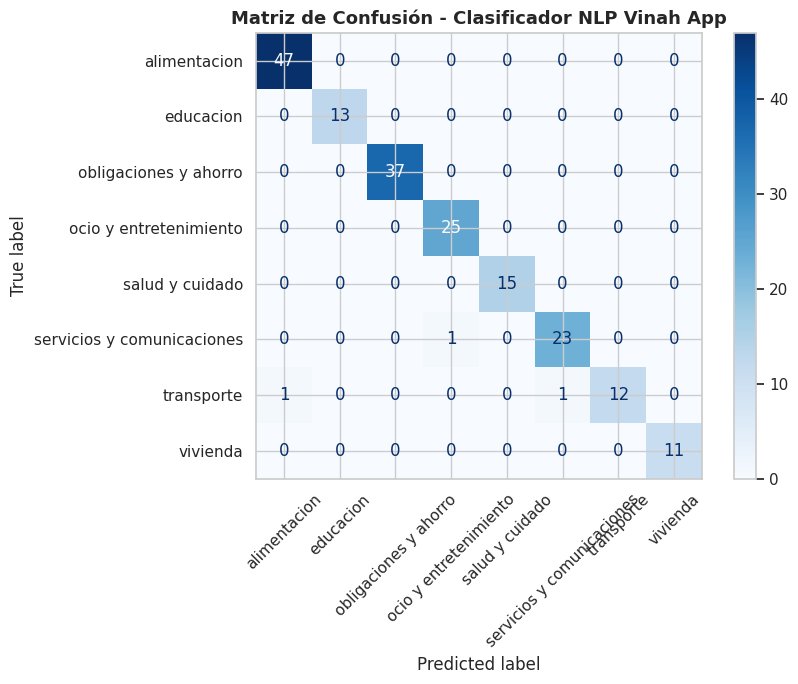

In [ ]:
# [8] Visualización 3: Matriz de confusión del clasificador
fig, ax = plt.subplots(figsize=(9, 7))
cm = confusion_matrix(y_test, y_pred, labels=modelo_pipeline.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=modelo_pipeline.classes_)
disp.plot(cmap='Blues', xticks_rotation=45, values_format='d', ax=ax)
plt.title('Matriz de Confusión - Clasificador NLP Vinah App', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

##Serializacion del modelo y obtencion del archivo .pkl

In [ ]:
# [9] Serialización del modelo para la API
joblib.dump(modelo_pipeline, 'modelo_perfil_financiero.pkl')
print('📦 Modelo exportado como modelo_perfil_financiero.pkl.')

📦 Modelo exportado como modelo_perfil_financiero.pkl.


In [ ]:
import os
import pickle

# 1. Creamos la carpeta donde guardaremos el modelo
os.makedirs('models', exist_ok=True)

# 2. Guardamos todo el pipeline en el archivo .pkl
with open('models/modelo_perfil_financiero.pkl', 'wb') as f:
    pickle.dump(modelo_pipeline, f)

print("✅ Modelo NLP guardado exitosamente en 'models/modelo_perfil_financiero.pkl'")

✅ Modelo NLP guardado exitosamente en 'models/modelo_perfil_financiero.pkl'


In [ ]:
from google.colab import files

# Descarga directa del archivo limpio a tu computadora
files.download("modelo_perfil_financiero.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

🗺️ EL VIAJE DEL DATO: Desde el CSV hasta el JSON

1.1. *Ingesta* de Datos (La Materia Prima):Petición API o CSV.El viaje comienza cuando el usuario sube un archivo CSV, un extracto bancario o envía un JSON a nuestra API. En este punto, los datos están "crudos". Tenemos texto suelto como "Compra en Coto 123" y números como 420.

2.2. *Preprocesamiento* (Preparar el terreno):Limpieza y Normalización.Antes de que la IA vea nada, Python (con Pandas) limpia el texto. Convierte "Compra en COTO 123" a minúsculas ("compra en coto 123").Aquí actúa nuestro TF-IDF Vectorizer: traduce esas palabras a una lista de números (vectores) que representan la importancia de cada término. Recuerda: ¡La IA NO entiende letras solo numeros!

3.3. *Inferencia* del *Modelo* (¡Aquí actúa la IA!):Predicción de Categorías.¡Este es el momento estelar del modelo de ML (.pkl)! El clasificador recibe los números del paso anterior. No mira los montos de dinero, solo analiza el patrón de las palabras.El modelo compara matemáticamente ese patrón con lo que aprendió en el entrenamiento y dice: "Hay un 95% de probabilidad de que esto sea 'Alimentación'". El modelo devuelve esa etiqueta.

4.4. *Lógica* de *Negocio* (El Evaluador):Métricas y Reglas Financieras.Una vez que la IA le puso etiqueta a cada gasto, el testigo pasa a nuestra función analizar_salud_financiera (el archivo evaluador.py).Aquí Python suma los gastos por categoría, calcula los ratios contra el ingreso mensual, mide el nivel de endeudamiento y define el perfil (Saludable, En observación, En riesgo) junto con las recomendaciones.

5.5. *Salida* *Estructurada* (El Producto Final):Formato JSON.Finalmente, todo ese conocimiento procesado se empaqueta en una estructura limpia de JSON. Este archivo viaja de regreso al usuario, a la app o a la base de datos para mostrarse en gráficos hermosos.

##Recomendaciones personalizadas

In [ ]:
# [10] Motor Experto Multi-Deuda y Recomendaciones Contextualizadas
def generar_recomendaciones_personalizadas(perfil, score_riesgo, ingreso_local, endeudamiento, frecuencia_ahorro, resumen_gastos, total_gastado, ratio_gasto, m_local):
    recomendaciones = []

    cat_dominante = max(resumen_gastos, key=resumen_gastos.get) if total_gastado > 0 else 'ocio y entretenimiento'
    monto_cat = resumen_gastos.get(cat_dominante, 0.0)
    pct_cat = round((monto_cat / total_gastado * 100), 1) if total_gastado > 0 else 0.0

    end_num = float(endeudamiento)
    ratio_num = round(float(ratio_gasto), 1)

    monto_obligaciones = resumen_gastos.get('obligaciones y ahorro', 0.0)
    monto_vivienda = resumen_gastos.get('vivienda', 0.0)
    monto_transporte = resumen_gastos.get('transporte', 0.0)

    if perfil == 'En riesgo':
        if end_num > 40:
            if monto_obligaciones > 0:
                recomendaciones.append(f'⚠️ Nivel de deuda elevado ({end_num}%): Revisa compromisos de préstamos personales, tarjetas o créditos bancarios ({monto_obligaciones:,.0f} {m_local}). Consolida pasivos para reducir cuotas.')
            elif monto_vivienda > 0:
                recomendaciones.append(f'⚠️ Tu crédito hipotecario/alquiler representa {monto_vivienda:,.0f} {m_local}. Evita asumir nuevos compromisos o préstamos mientras regularizas tu presupuesto.')
            else:
                recomendaciones.append(f'⚠️ Nivel de endeudamiento elevado del {end_num}%. Prioriza cancelar deudas pendientes con préstamos o terceros.')
        elif ratio_num > 80:
            recomendaciones.append(f'🚨 Tus gastos representan el {ratio_num}% de tus ingresos. Es urgente congelar nuevos créditos y recortar compras en {cat_dominante} ({monto_cat:,.0f} {m_local}).')
        else:
            recomendaciones.append(f'⚠️ Riesgo financiero elevado. Reduce egresos en la categoría principal "{cat_dominante}" ({pct_cat}% del total).')

        if str(frecuencia_ahorro).lower() in ['baja', 'ninguna', '0']:
            recomendaciones.append('Construye un fondo de reserva de emergencia antes de solicitar préstamos adicionales.')
        else:
            recomendaciones.append(f'Limita compras en la categoría {cat_dominante} para recuperar tu superávit mensual.')

    elif perfil == 'En observacion':
        if end_num >= 25:
            if monto_vivienda > monto_obligaciones and monto_vivienda > 0:
                recomendaciones.append(f'💡 Tu cuota de vivienda/préstamo del hogar ({monto_vivienda:,.0f} {m_local}) absorbe parte importante de tus ingresos. Mantén acotados los préstamos personales.')
            elif monto_transporte > 0 and cat_dominante == 'transporte':
                recomendaciones.append(f'💡 Los gastos de vehículo/cuota de transporte representan {monto_transporte:,.0f} {m_local}. Revisa gastos asociados como seguro o mantenimiento.')
            else:
                recomendaciones.append(f'💡 Tu nivel de endeudamiento es del {end_num}%. Limita el uso de tarjeta de crédito o la solicitud de préstamos a plazo.')
        elif cat_dominante in ['ocio y entretenimiento', 'alimentacion'] and pct_cat > 30:
            recomendaciones.append(f'💡 La categoría "{cat_dominante}" representa el {pct_cat}% de tus gastos ({monto_cat:,.0f} {m_local}). Fija un límite semanal para compras discretas.')
        else:
            recomendaciones.append(f'💡 Tus gastos suman el {ratio_num}% de tus ingresos. Controla pequeños consumos en {cat_dominante}.')

        if str(frecuencia_ahorro).lower() in ['baja', 'media']:
            recomendaciones.append('Automatiza la transferencia del 10% de tus ingresos a un fondo de ahorro apenas cobres tu sueldo.')
        else:
            recomendaciones.append(f'Monitorea la categoría {cat_dominante} para evitar pasar al perfil de riesgo.')

    else:  # Perfil Saludable
        recomendaciones.append(f'✅ ¡Excelente salud financiera! Mantienes tus gastos en un {ratio_num}% de tus ingresos y compromisos crediticios sostenibles ({end_num}%).')
        if pct_cat > 0:
            recomendaciones.append(f'📈 Con tu capacidad de ahorro actual, explora herramientas como Fondos Comunes o Plazos Fijos para hacer crecer tu capital excedente.')

    return recomendaciones[:2]

 **4: (La parte de prueba/backend): Prueba de Inferencia / Simulación de Endpoints API**

In [ ]:
# [11] Función Principal de Inferencia para Backend API
def analizar_salud_financiera(ingreso_mensual, nivel_endeudamiento, frecuencia_ahorro, transacciones, modelo, moneda_local_usuario='ARS'):
    try:
        m_local = str(moneda_local_usuario).upper().strip()
        descripciones_limpias = [normalizar_texto_gasto(t.get('descripcion', '')) for t in transacciones]

        try:
            categorias_predichas = modelo.predict(descripciones_limpias)
        except Exception:
            categorias_predichas = ['ocio y entretenimiento'] * len(descripciones_limpias)

        detalles_transacciones = []
        valores_locales = []

        for t, cat_pred in zip(transacciones, categorias_predichas):
            m_orig_val = float(t.get('valor', 0.0))
            m_orig_curr = str(t.get('moneda', 'USD')).upper()
            m_local_val, tasa = convertir_divisa(m_orig_val, m_orig_curr, m_local)

            valores_locales.append(m_local_val)
            detalles_transacciones.append({
                'descripcion_original': t.get('descripcion', ''),
                'categoria_asignada': cat_pred,
                'monto_original': round(m_orig_val, 2),
                'moneda_original': m_orig_curr,
                'monto_local_convertido': round(m_local_val, 2),
                'moneda_local_usuario': m_local,
                'tasa_cambio_aplicada': tasa
            })

        resumen_gastos = {
            'vivienda': 0.0,
            'servicios y comunicaciones': 0.0,
            'alimentacion': 0.0,
            'transporte': 0.0,
            'salud y cuidado': 0.0,
            'educacion': 0.0,
            'ocio y entretenimiento': 0.0,
            'obligaciones y ahorro': 0.0
        }

        total_gastado = 0.0
        for cat_pred, val in zip(categorias_predichas, valores_locales):
            if cat_pred in resumen_gastos:
                resumen_gastos[cat_pred] = round(resumen_gastos[cat_pred] + val, 2)
            else:
                resumen_gastos['ocio y entretenimiento'] = round(resumen_gastos.get('ocio y entretenimiento', 0.0) + val, 2)
            total_gastado += val

        ingreso_local_val, _ = convertir_divisa(ingreso_mensual, 'USD', m_local) if float(ingreso_mensual) < 10000 else (float(ingreso_mensual), 1.0)
        ratio_gasto = ((total_gastado / ingreso_local_val) * 100) if ingreso_local_val > 0 else 0.0

        score_riesgo = 0
        end_num = float(nivel_endeudamiento)
        if end_num > 40: score_riesgo += 40
        elif end_num > 25: score_riesgo += 25
        else: score_riesgo += 5

        if ratio_gasto > 80: score_riesgo += 40
        elif ratio_gasto > 50: score_riesgo += 20
        else: score_riesgo += 5

        frecuencias = {'baja': 20, 'media': 10, 'alta': 0}
        score_riesgo += frecuencias.get(str(frecuencia_ahorro).lower(), 10)

        if score_riesgo >= 60:
            perfil = 'En riesgo'
            prob = round(min(score_riesgo / 100.0, 0.99), 2)
        elif score_riesgo >= 30:
            perfil = 'En observacion'
            prob = round(score_riesgo / 100.0, 2)
        else:
            perfil = 'Saludable'
            prob = round(1.0 - (score_riesgo / 100.0), 2)

        recomendaciones = generar_recomendaciones_personalizadas(
            perfil=perfil,
            score_riesgo=score_riesgo,
            ingreso_local=ingreso_local_val,
            endeudamiento=end_num,
            frecuencia_ahorro=frecuencia_ahorro,
            resumen_gastos=resumen_gastos,
            total_gastado=total_gastado,
            ratio_gasto=ratio_gasto,
            m_local=m_local
        )

        return {
            'perfil_financiero': perfil,
            'probabilidad_riesgo': prob,
            'moneda_local_usuario': m_local,
            'resumen_gastos_por_categoria': resumen_gastos,
            'total_gastado_local': round(total_gastado, 2),
            'ratio_gasto_ingreso_pct': round(ratio_gasto, 2),
            'recomendaciones': recomendaciones,
            'detalles_transacciones_procesadas': detalles_transacciones
        }
    except Exception as general_error:
        return {
            'perfil_financiero': 'En observacion',
            'probabilidad_riesgo': 0.5,
            'moneda_local_usuario': moneda_local_usuario,
            'resumen_gastos_por_categoria': {c: 0.0 for c in ['vivienda', 'servicios y comunicaciones', 'alimentacion', 'transporte', 'salud y cuidado', 'educacion', 'ocio y entretenimiento', 'obligaciones y ahorro']},
            'total_gastado_local': 0.0,
            'ratio_gasto_ingreso_pct': 0.0,
            'recomendaciones': ['Revisa las transacciones ingresadas.', 'Automatiza tu ahorro mensual.'],
            'detalles_transacciones_procesadas': []
        }

**Nota de Integración**: Esta sección demuestra la carga del archivo .pkl generado y simula/valida la respuesta que procesará el servicio api.py (FastAPI) para enviar las predicciones a la interfaz visual.

In [ ]:
# [12] Prueba de ejecución
ejemplo_json_prueba = {
    'ingreso_mensual': 1200.0,
    'nivel_endeudamiento': 45.0,
    'frecuencia_ahorro': 'Baja',
    'moneda_local_usuario': 'COP',
    'transacciones': [
        {'descripcion': '🏦 Pago cuota prestamo bancario', 'valor': 450000.0, 'moneda': 'COP'},
        {'descripcion': '🛒 SUPERMERCADO EXITO compras', 'valor': 200000.0, 'moneda': 'COP'}
    ]
}

res = analizar_salud_financiera(
    ingreso_mensual=ejemplo_json_prueba['ingreso_mensual'],
    nivel_endeudamiento=ejemplo_json_prueba['nivel_endeudamiento'],
    frecuencia_ahorro=ejemplo_json_prueba['frecuencia_ahorro'],
    transacciones=ejemplo_json_prueba['transacciones'],
    modelo=modelo_pipeline,
    moneda_local_usuario=ejemplo_json_prueba['moneda_local_usuario']
)

print('\n=== PRUEBA DE RESPUESTA JSON MULTI-DEUDA ===')
print(json.dumps(res, indent=2, ensure_ascii=False))


=== PRUEBA DE RESPUESTA JSON MULTI-DEUDA ===
{
  "perfil_financiero": "En riesgo",
  "probabilidad_riesgo": 0.65,
  "moneda_local_usuario": "COP",
  "resumen_gastos_por_categoria": {
    "vivienda": 0.0,
    "servicios y comunicaciones": 0.0,
    "alimentacion": 200000.0,
    "transporte": 0.0,
    "salud y cuidado": 0.0,
    "educacion": 0.0,
    "ocio y entretenimiento": 0.0,
    "obligaciones y ahorro": 450000.0
  },
  "total_gastado_local": 650000.0,
  "ratio_gasto_ingreso_pct": 13.54,
  "recomendaciones": [
    "⚠️ Nivel de deuda elevado (45.0%): Revisa compromisos de préstamos personales, tarjetas o créditos bancarios (450,000 COP). Consolida pasivos para reducir cuotas.",
    "Construye un fondo de reserva de emergencia antes de solicitar préstamos adicionales."
  ],
  "detalles_transacciones_procesadas": [
    {
      "descripcion_original": "🏦 Pago cuota prestamo bancario",
      "categoria_asignada": "obligaciones y ahorro",
      "monto_original": 450000.0,
      "moneda_or